<a href="https://colab.research.google.com/github/antoniot73/Practica_sports-classifier/blob/main/CNN_Clasificador_Deportes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks

# Importar Librerías

In [198]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [199]:
import tensorflow as tf
import keras
from keras.utils import to_categorical
# Importación de Input para definir la entrada del modelo: keras es una API pública y estable
from keras import Input
# from tensorflow.python.keras.layers import Input (usa una ruta interna de TensorFlow)
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import BatchNormalization
from keras.layers import LeakyReLU

# Cargar set de Imágenes

In [200]:
# # # # # #
# Conexión con Google Drive acceso a imágenes de entrenamiento .../sportimages/golf
# Conexión con Google Drive acceso a imágenes de entrenamiento .../sportimages/basket
# Conexión con Google Drive acceso a imágenes de pruebas .../test_images
from google.colab import drive
import os

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [201]:
# Ruta original del script
dirname = os.path.join(os.getcwd(), 'drive/MyDrive/Colab_Notebooks/sportimages')
imgpath = dirname + os.sep

images = []
directories = []
dircount = []
prevRoot=''
cant=0

print("leyendo imagenes de ",imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        if re.search(r"\.(jpg|jpeg|png|bmp|tiff)$", filename):
            cant=cant+1
            filepath = os.path.join(root, filename)
            image = plt.imread(filepath)
            images.append(image)
            b = "Leyendo..." + str(cant)
            print (b, end="\r")
            if prevRoot !=root:
                print(root, cant)
                prevRoot=root
                directories.append(root)
                dircount.append(cant)
                cant=0
dircount.append(cant)

dircount = dircount[1:]
# Evita que se rompa el código si no encuentra el dataset
if len(dircount) > 0:
    dircount[0]=dircount[0]+1
# dircount[0]=dircount[0]+1
print('Directorios leidos:',len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:',sum(dircount))

leyendo imagenes de  /content/drive/MyDrive/Colab_Notebooks/sportimages/
/content/drive/MyDrive/Colab_Notebooks/sportimages/golf 1
/content/drive/MyDrive/Colab_Notebooks/sportimages/basket 9768
Directorios leidos: 2
Imagenes en cada directorio [9769, 1854]
suma Total de imagenes en subdirs: 11623


# Creamos las etiquetas

In [202]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))

Cantidad etiquetas creadas:  11623


In [203]:
deportes=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    deportes.append(name[len(name)-1])
    indice=indice+1

0 golf
1 basket


In [204]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy

# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  2
Output classes :  [0 1]


# Creamos Sets de Entrenamiento y Test

In [205]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (9298, 21, 28, 3) (9298,)
Testing data shape :  (2325, 21, 28, 3) (2325,)


Text(0.5, 1.0, 'Ground Truth : 0')

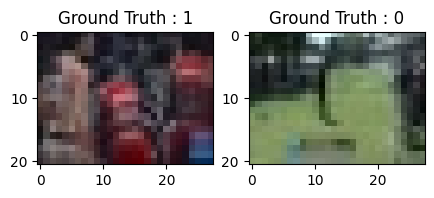

In [206]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

In [207]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X / 255.
test_X = test_X / 255.

## Hacemos el One-hot Encoding para la red

In [208]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 1
After conversion to one-hot: [0. 1.]


# Creamos el Set de Entrenamiento y Validación

In [209]:
#Mezclar todo y crear los grupos de entrenamiento y testing
train_X,valid_X,train_label,valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=13)

In [210]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)

(7438, 21, 28, 3) (1860, 21, 28, 3) (7438, 2) (1860, 2)


# Creamos el modelo de CNN

In [211]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3 # Valor inicial de learning rate. El valor 1e-3 corresponde con 0.001
epochs = 6 # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 64 # cantidad de imágenes que se toman a la vez en memoria

In [212]:
sport_model = Sequential()
sport_model.add(Input(shape=(21,28,3)))
sport_model.add(Conv2D(32, kernel_size=(3, 3), activation='linear', padding='same'))
# sport_model.add(Conv2D(32, kernel_size=(3, 3),activation='linear',padding='same',input_shape=(21,28,3)))
sport_model.add(LeakyReLU(negative_slope=0.1))
sport_model.add(MaxPooling2D((2, 2),padding='same'))
sport_model.add(Dropout(0.5))

sport_model.add(Flatten())
sport_model.add(Dense(32, activation='linear'))
sport_model.add(LeakyReLU(negative_slope=0.1))
sport_model.add(Dropout(0.5))
sport_model.add(Dense(nClasses, activation='softmax'))

In [213]:
sport_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 21, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 21, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │       157,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,690 (619.88 KB)

 Trainable params: 158,690 (619.88 KB)

 Non-trainable params: 0 (0.00 B)

In [214]:
sport_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adagrad(learning_rate=INIT_LR, weight_decay=INIT_LR / 100),metrics=['accuracy'])

# Entrenamos el modelo: Aprende a clasificar imágenes

In [215]:
# este paso puede tomar varios minutos, dependiendo de tu ordenador, cpu y memoria ram libre
sport_train = sport_model.fit(
    train_X,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(valid_X, valid_label)
)
# sport_train = sport_model.fit(train_X, train_label, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(valid_X, valid_label))

Epoch 1/6
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8122 - loss: 0.4943 - val_accuracy: 0.8478 - val_loss: 0.4068
Epoch 2/6
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8352 - loss: 0.4307 - val_accuracy: 0.8478 - val_loss: 0.3800
Epoch 3/6
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8356 - loss: 0.4059 - val_accuracy: 0.8478 - val_loss: 0.3550
Epoch 4/6
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8400 - loss: 0.3742 - val_accuracy: 0.8478 - val_loss: 0.3231
Epoch 5/6
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8455 - loss: 0.3496 - val_accuracy: 0.8548 - val_loss: 0.2923
Epoch 6/6
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8537 - loss: 0.3302 - val_accuracy: 0.8613 - val_loss: 0.2702


In [216]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
#sport_model.save("sports_mnist.h5py")
# sport_model.save("sports_mnist.keras")
sport_model.save("/content/drive/MyDrive/Colab_Notebooks/keras/sports_mnist.keras")

# Evaluamos la red

In [217]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8654 - loss: 0.2688


In [218]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.26882362365722656
Test accuracy: 0.865376353263855


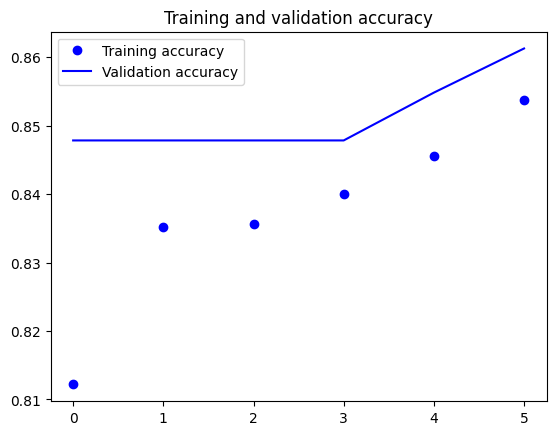

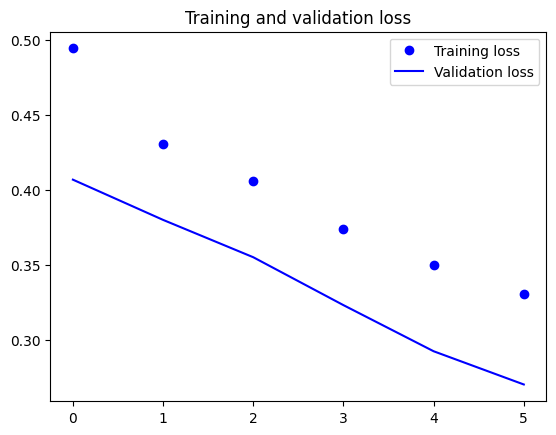

In [219]:
accuracy = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss = sport_train.history['loss']
val_loss = sport_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [220]:
predicted_classes2 = sport_model.predict(test_X)

73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [221]:
predicted_classes=[]
for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))
predicted_classes=np.array(predicted_classes)

In [222]:
predicted_classes.shape, test_Y.shape

((2325,), (2325,))

# Aprendamos de los errores: Qué mejorar

Found 2012 correct labels


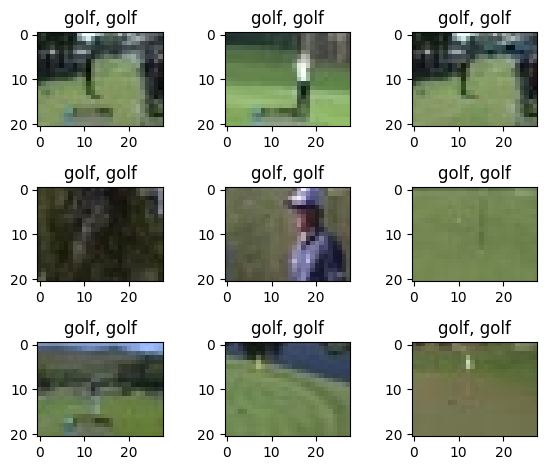

In [223]:
correct = np.where(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct].reshape(21,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[correct]],
                                                    deportes[test_Y[correct]]))

    plt.tight_layout()

Found 313 incorrect labels


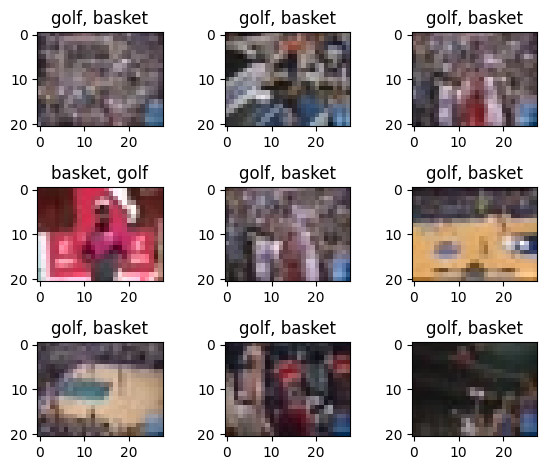

In [224]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(21,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[incorrect]],
                                                    deportes[test_Y[incorrect]]))
    plt.tight_layout()

In [225]:
target_names = ["Class {}".format(i) for i in range(nClasses)]
# print(classification_report(test_Y, predicted_classes, target_names=target_names))
print(classification_report(test_Y, predicted_classes, target_names=target_names, zero_division=0))

              precision    recall  f1-score   support

     Class 0       0.86      1.00      0.93      1975
     Class 1       0.91      0.12      0.21       350

    accuracy                           0.87      2325
   macro avg       0.89      0.56      0.57      2325
weighted avg       0.87      0.87      0.82      2325



# Prediccion de una nueva imagen

In [226]:
from skimage.transform import resize

images = []
# AQUI ESPECIFICAMOS UNAS IMAGENES
filenames = ['/content/drive/MyDrive/Colab_Notebooks/test_images/golf_0466.jpg']


for filepath in filenames:
    image = plt.imread(filepath,0)
    image_resized = resize(image, (21, 28), anti_aliasing=True, clip=False, preserve_range=True)
    images.append(image_resized)

X = np.array(images, dtype=np.uint8) #convierto de lista a numpy
test_X = X.astype('float32')
test_X = test_X / 255.

predicted_classes = sport_model.predict(test_X)

for i, img_tagged in enumerate(predicted_classes):
    print(filenames[i], deportes[img_tagged.tolist().index(max(img_tagged))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
/content/drive/MyDrive/Colab_Notebooks/test_images/golf_0466.jpg golf
